In [ ]:
import os 
import numpy as np
import tarfile
import huggingface_hub as hf
import dotenv

#cleaned up dataset 
dotenv.load_dotenv()
repo_id = "bekalemu/grid-corpus-compressed"
hf_token= os.getenv("HF_TOKEN")

local_path  = hf.snapshot_download(
    repo_id=repo_id,
    token=hf_token,
    repo_type="dataset",
    local_dir = "dataset",
    
)


data_dir = os.path.join("dataset") 
speakers = [speaker for speaker in os.listdir(data_dir) if speaker.endswith('.gz')]
for speaker in speakers:
    speaker_path = os.path.join(data_dir, speaker)
    with tarfile.open(speaker_path) as tar:
        tar.extractall(data_dir)


#delete the .tar.gz files
for speaker in speakers:
    if speaker.endswith('.gz'):
        os.remove(os.path.join(data_dir, speaker))






    

In [57]:
import string 
chars = list(string.ascii_lowercase) + [' ']
blank_token = '-'
vocab = [blank_token] + chars
char2idx = {char: idx for idx, char in enumerate(vocab)}     

In [59]:
from torch.utils.data import Dataset, DataLoader 
from torch.nn.utils.rnn import pad_sequence 
from torch.utils.data import random_split
from torchvision import transforms
import torch
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class LipReadingDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir 
        self.transform = transform
        self.video_files = []
        self.align_files = []
        for speaker in os.listdir(data_dir):
            
            speaker_dir = os.path.join(data_dir, speaker)
            if not os.path.isdir(speaker_dir):
                continue
            for file in os.listdir(speaker_dir):
                if file.endswith(".mp4"):
                    self.video_files.append(os.path.join(speaker_dir, file))
                    alignment_file = os.path.join(speaker_dir,'align',file.replace("_lip_roi.mp4", ".align"))
                    self.align_files.append(alignment_file)
                    
                    
       
    def __len__(self):
            return len(self.video_files)

    def __getitem__(self, idx):
            roi_path = self.video_files[idx]
            align_path = self.align_files[idx]
            """sample align file 
                0 23750 sil
                23750 29500 bin
                29500 34000 blue
                34000 35500 at
                35500 41000 f
                41000 47250 two
                47250 53000 now
                53000 74500 sil"""
            

            roi_data = []
            cap = cv2.VideoCapture(roi_path)
            while True:
                ret, frame = cap.read()
                if not ret:
                    break 
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                roi_data.append(frame)
            cap.release()
            roi_data = np.array(roi_data)


            if self.transform:            
                roi_data = torch.tensor(roi_data, dtype=torch.float32,device=device)
                roi_data = self.transform(roi_data)
                roi_data = roi_data.unsqueeze(0) 
                
                
            with open(align_path, 'r') as f:
                lines = f.readlines()
                ids= []
                for line in lines:
                    start, end, word = line.strip().split() 
                    chars = list(word.lower())
                    ids.extend([char2idx[char] for char in chars if char in char2idx])
                ids = np.array(ids, dtype=np.int32)
                input_length = roi_data.shape[1]
                return roi_data, torch.tensor(ids, dtype=torch.int32, device=device), input_length, len(ids)


#should resize further to 50 x 100 (128 x 128 is too big for our limited computational resources)
inp_transform=transforms.Compose([
     transforms.Resize((100, 50))
])

dataset = LipReadingDataset(data_dir, transform=inp_transform) 
train_size = int(0.95 * len(dataset)) 
val_size = len(dataset) - train_size 

train_dataset, val_dataset = random_split(dataset, [train_size, val_size],generator=torch.Generator().manual_seed(42))

import torch.nn.functional as F

def collate_fn(batch):
    roi_data, ids, input_lengths, output_lengths = zip(*batch)

    
    ids = pad_sequence(ids, batch_first=True, padding_value=0)

    
    max_len = max(t.shape[1] for t in roi_data)

    padded_roi = []
    for t in roi_data:
        pad_len = max_len - t.shape[1]
        
        padded = F.pad(t, (0, 0, 0, 0, 0, pad_len))
        padded_roi.append(padded)

    roi_data = torch.stack(padded_roi)

    return roi_data, ids, input_lengths, output_lengths
   
  

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)  
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)      



In [60]:
roi,ids, _,_ = dataset[0]
roi.shape  

torch.Size([1, 75, 100, 50])

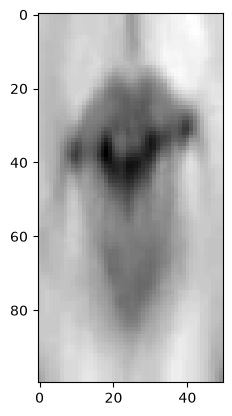

In [61]:
#plot sample roi imafe
sample_roi, sample_ids,input_lengths,output_lengths = dataset[0]
# print(sample_roi.shape)
sample_roi= sample_roi.squeeze(0)
import matplotlib.pyplot as plt
plt.imshow(sample_roi[5], cmap='gray') 

In [62]:
class LipReadingModel(torch.nn.Module):
    def __init__(self,  hidden_size=128):
        super(LipReadingModel, self).__init__()
        #input shape is (batch_size, 75, 100, 50). 
        self.conv1 = torch.nn.Conv3d(in_channels=1, out_channels=16, kernel_size=(3,3,3), stride=(1,1,1), padding=(1,1,1))
      
        self.pool1 = torch.nn.MaxPool3d(kernel_size=(1,2,2), stride=(1,2,2))
        #(b,16, 75, 50,25)

        self.conv2 = torch.nn.Conv3d(in_channels=16, out_channels=32, kernel_size=(3,3,3), stride=(1,1,1), padding=(1,1,1))
      
        self.pool2 = torch.nn.MaxPool3d(kernel_size=(1,2,2), stride=(1,2,2))
        #(b, 32, 75, 25, 12)


        self.conv3 = torch.nn.Conv3d(in_channels=32, out_channels=64, kernel_size=(3,3,3), stride=(1,1,1), padding=(1,1,1))
        
        self.pool3 = torch.nn.MaxPool3d(kernel_size=(1,2,2), stride=(1,2,2))
        #(b, 64, 75, 12, 6)


        self.gru = torch.nn.GRU(input_size=64*12*6, hidden_size=hidden_size, num_layers=1, batch_first=True, bidirectional=True)
        self.linear = torch.nn.Linear(hidden_size*2 , len(vocab))
    
    def forward(self, x):
        x= self.conv1(x)
        x= self.pool1(x)

        x=self.conv2(x)
        x = self.pool2(x)
        x= self.conv3(x)
        x = self.pool3(x)

        #reshape x to (batch_size, 75, 64*12*6)
        # print(x.shape)
        x = x.view(x.size(0), x.size(2),-1)
        # print(x.shape)
        x,_ = self.gru(x)
        x = self.linear(x)
        return x 

In [63]:
model = LipReadingModel()
model.to(device)

criterion = torch.nn.CTCLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
epochs = 1
log_every = 10
save_every = 400

def validate():
    model.eval()
    val_loss = 0 
   
    with torch.no_grad():
        for batch_idx, (roi_data, ids,input_lengths, output_lengths) in enumerate(val_dataloader):
            roi_data = roi_data.to(device)
            ids = ids.to(device)
            outputs = model(roi_data)
            log_probs = torch.nn.functional.log_softmax(outputs, dim=2)
            log_probs = log_probs.permute(1, 0 , 2) #(T,N,C)
            loss = criterion(log_probs, ids, torch.tensor(input_lengths, dtype=torch.int32, device=device), torch.tensor(output_lengths, dtype=torch.int32, device=device))
            val_loss += loss.item()
    return val_loss / len(val_dataloader)

def save_model(epoch, batch_idx, val_loss, best=False):
    state = {
        'epoch': epoch,
        'batch_idx': batch_idx,
        "optimizer_state_dict": optimizer.state_dict(),
        "model_state_dict": model.state_dict(),
        "val_loss": val_loss}
    if best:
        torch.save(state, f"lip_reading_model_best.pt")
    else:
        torch.save(state, f"latest.pt")

def train():
    best_val_loss = float('inf')
    for epoch in range(epochs):
        model.train()
        for batch_idx, (roi_data, ids,input_lengths, output_lengths) in enumerate(train_dataloader):
            optimizer.zero_grad()
            roi_data = roi_data.to(device)
            ids = ids.to(device)
            outputs = model(roi_data)
            log_probs = torch.nn.functional.log_softmax(outputs, dim=2)
            
            log_probs = log_probs.permute(1, 0, 2)  #(T,N, C)
            
            loss = criterion(log_probs, ids, torch.tensor(input_lengths, dtype=torch.int32, device=device),torch.tensor(output_lengths, dtype=torch.int32, device=device)) 
            loss.backward()
            optimizer.step()
            
           
            if batch_idx % log_every == 0:
                val_loss = validate()
                print(f"Epoch [{epoch+1}/{epochs}], Batch [{batch_idx+1}/{len(train_dataloader)}], Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}")

                if val_loss < best_val_loss:
                    best_val_loss = val_loss 
                    save_model(epoch, batch_idx, val_loss, best=True)
                if batch_idx % save_every == 0:
                    save_model(epoch, batch_idx, val_loss)    

In [ ]:
if __name__ == "__main__":
    train()      